We use XGBoost here to do time series forecasting. 

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import xgboost
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit


Below is the function that will conduct the hyperparameter optimization. 

In [5]:
def getBestXGBoostModel(x_train, y_train, x_test, y_test):
    param_grid = {
        'max_depth': [3, 5, 7, 9, 11, 13],
        'learning_rate': [0.001, 0.005, 0.01, 0.05, 0.1],
        'subsample': [0.8, 0.9, 1.0], 
        'colsample_bytree': [0.8, 0.9, 1.0]
    }

    #using xgboost with early stopping
    base_xgb = xgboost.XGBRegressor(
        n_estimators=2000, 
        early_stopping_rounds=50, 
        random_state=42, 
        n_jobs=-1
    )
    
    tscv = TimeSeriesSplit(n_splits=4)

    #run randomized search to optimize model 
    tuner = RandomizedSearchCV(
        estimator=base_xgb,
        param_distributions=param_grid,
        n_iter=30,           
        scoring='neg_mean_squared_error', 
        cv=tscv, 
        verbose=1,        
        random_state=42,
        n_jobs=-1            
    )
    
    #holdout set for early stopping
    split_idx = int(len(x_train) * 0.9)
    x_train_cv, x_eval = x_train.iloc[:split_idx], x_train.iloc[split_idx:]
    y_train_cv, y_eval = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

    print("Running tuner with early stopping...")
    
    tuner.fit(
        x_train_cv, 
        y_train_cv,
        eval_set=[(x_eval, y_eval)],
        verbose=False 
    )
    
    best_model = tuner.best_estimator_
    
    print("\nBest Settings Found:")
    for param, value in tuner.best_params_.items():
        print(f" - {param}: {value}")
    
    print(f"Optimal trees used: {best_model.best_iteration}")
    
    optimized_predictions = best_model.predict(x_test)
    opt_mse = mean_squared_error(y_test, optimized_predictions)
    
    print(f"New Mean Absolute Error: {opt_mse:,.0f}")
    
    return best_model

We load the training and test data files. These files contain environmental data such as the irradiance (power from the Sun), wind speed, ambient air temperature, and wind direction as well as what we want to predict, the AC power output in kW. We will not use the wind direction for predictions but will use the other environmental data as features. We will in addition add the hour of the day and month as features.

In [6]:
df_train = pd.read_csv('/Users/varungudibanda/Desktop/ErdosProject/training_data.csv')
df_test = pd.read_csv('/Users/varungudibanda/Desktop/ErdosProject/test_data.csv')


#get times/dates
df_train['measured_on'] = pd.to_datetime(df_train['measured_on'], utc=True).dt.tz_convert('America/Los_Angeles')
df_test['measured_on'] = pd.to_datetime(df_test['measured_on'], utc=True).dt.tz_convert('America/Los_Angeles')

# add hour and month as features
df_train['hour'] = df_train['measured_on'].dt.hour
df_train['month'] = df_train['measured_on'].dt.month
df_test['hour'] = df_test['measured_on'].dt.hour
df_test['month'] = df_test['measured_on'].dt.month

X_train = df_train[['poa_global', 'temp_air', 'wind_speed_mph', 'hour', 'month']]
Y_train = df_train['actual_power_kw']

X_test = df_test[['poa_global', 'temp_air', 'wind_speed_mph', 'hour', 'month']]
Y_test = df_test[['actual_power_kw']]

We split the training data in multiple sets and will build an optimal model over each split. 

In [7]:
split_index1 =  int(len(df_train) * 0.5)
split_index2 =  int(len(df_train) * 0.6)
split_index3 =  int(len(df_train) * 0.7)
split_index4 =  int(len(df_train) * 0.8)
split_index5 =  int(len(df_train) * 0.9)
split_index6 =  int(len(df_train) * 1)

split_indices = [split_index1, split_index2, split_index3, split_index4, split_index5, split_index6]

split_X = []
split_Y = []

for i in range(len(split_indices)):
    split_index = split_indices[i]
    split_X.append(X_train.iloc[:split_index])
    split_Y.append(Y_train.iloc[:split_index])
    

We now train the models and use the function from before to do hyperparameter optimization for the XGBoost models. We use an MSE loss function here and use early stopping to help prevent overfitting (and also improve runtime). 

In [8]:
bestModels = []

for i in range(len(split_indices)):
    print(f'on split index {i}')
    bestModel = getBestXGBoostModel(split_X[i], split_Y[i],X_test, Y_test)
    bestModels.append(bestModel)

on split index 0
Running tuner with early stopping...
Fitting 4 folds for each of 30 candidates, totalling 120 fits


/opt/anaconda3/envs/erdos_project/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Settings Found:
 - subsample: 0.9
 - max_depth: 3
 - learning_rate: 0.005
 - colsample_bytree: 1.0
Optimal trees used: 1995
New Mean Absolute Error: 1,829
on split index 1
Running tuner with early stopping...
Fitting 4 folds for each of 30 candidates, totalling 120 fits


/opt/anaconda3/envs/erdos_project/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Settings Found:
 - subsample: 0.9
 - max_depth: 3
 - learning_rate: 0.005
 - colsample_bytree: 1.0
Optimal trees used: 1047
New Mean Absolute Error: 1,813
on split index 2
Running tuner with early stopping...
Fitting 4 folds for each of 30 candidates, totalling 120 fits


...


Best Settings Found:
 - subsample: 0.9
 - max_depth: 3
 - learning_rate: 0.005
 - colsample_bytree: 1.0
Optimal trees used: 1640
New Mean Absolute Error: 1,679
on split index 4
Running tuner with early stopping...
Fitting 4 folds for each of 30 candidates, totalling 120 fits


/opt/anaconda3/envs/erdos_project/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Settings Found:
 - subsample: 0.9
 - max_depth: 3
 - learning_rate: 0.005
 - colsample_bytree: 1.0
Optimal trees used: 1754
New Mean Absolute Error: 1,677
on split index 5
Running tuner with early stopping...
Fitting 4 folds for each of 30 candidates, totalling 120 fits


/opt/anaconda3/envs/erdos_project/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Settings Found:
 - subsample: 1.0
 - max_depth: 3
 - learning_rate: 0.05
 - colsample_bytree: 0.9
Optimal trees used: 360
New Mean Absolute Error: 1,679


Now we will just list all the MSEs for each optimal model over each split. We see that the MSEs are converging to around the same value. 

In [10]:
for model in bestModels:
    predictions = model.predict(X_test)
    mse = mean_squared_error(Y_test, predictions)
    print(mse)

1828.8135986328125
1812.7357177734375
1717.6640625
1679.43359375
1677.0830078125
1678.7994384765625


We make our predictions using the model with lowest MSE. We plot the importance of the features. We see that irradiance (poa_global) has the highest importance with time features (hour and month) coming next. 

<Figure size 1000x600 with 0 Axes>

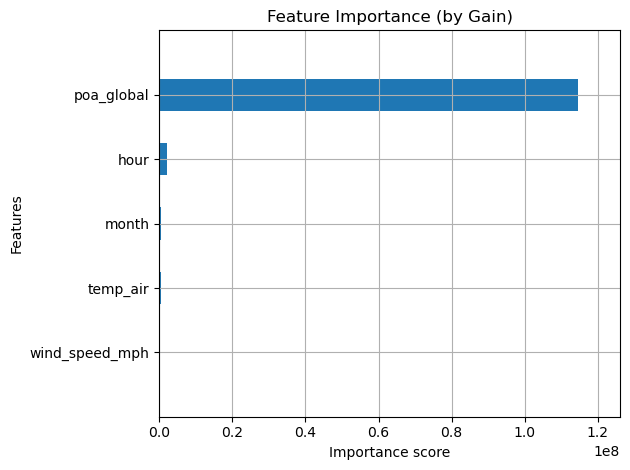

In [13]:
final_model = bestModels[-2] 
final_predictions = final_model.predict(X_test)

plt.figure(figsize=(10, 6))
xgboost.plot_importance(final_model, importance_type='gain', max_num_features=10, height=0.5, show_values=False)
plt.title('Feature Importance (by Gain)')
plt.tight_layout()
plt.show()

We then plot our predictions.

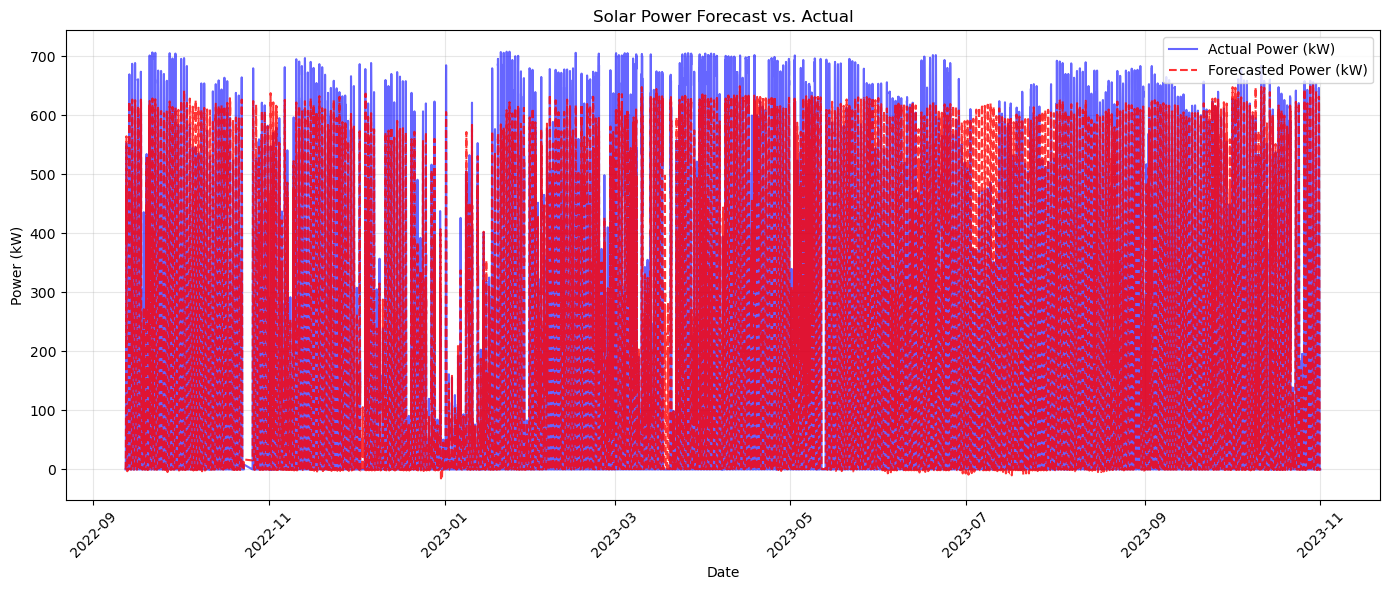

In [14]:
test_dates = pd.to_datetime(df_test['measured_on'], utc=True)

plt.figure(figsize=(14, 6))
plot_ind = -1

plt.plot(test_dates[:plot_ind], Y_test.values[:plot_ind], label='Actual Power (kW)', color='blue', alpha=0.6, linewidth=1.5)
plt.plot(test_dates[:plot_ind], final_predictions[:plot_ind], label='Forecasted Power (kW)', color='red', alpha=0.8, linewidth=1.5, linestyle='--')

plt.title('Solar Power Forecast vs. Actual')
plt.xlabel('Date')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

We zoom in to just a 10 day prediction. We see that the overall trend is captured decently but that it fails to capture the peaks. 

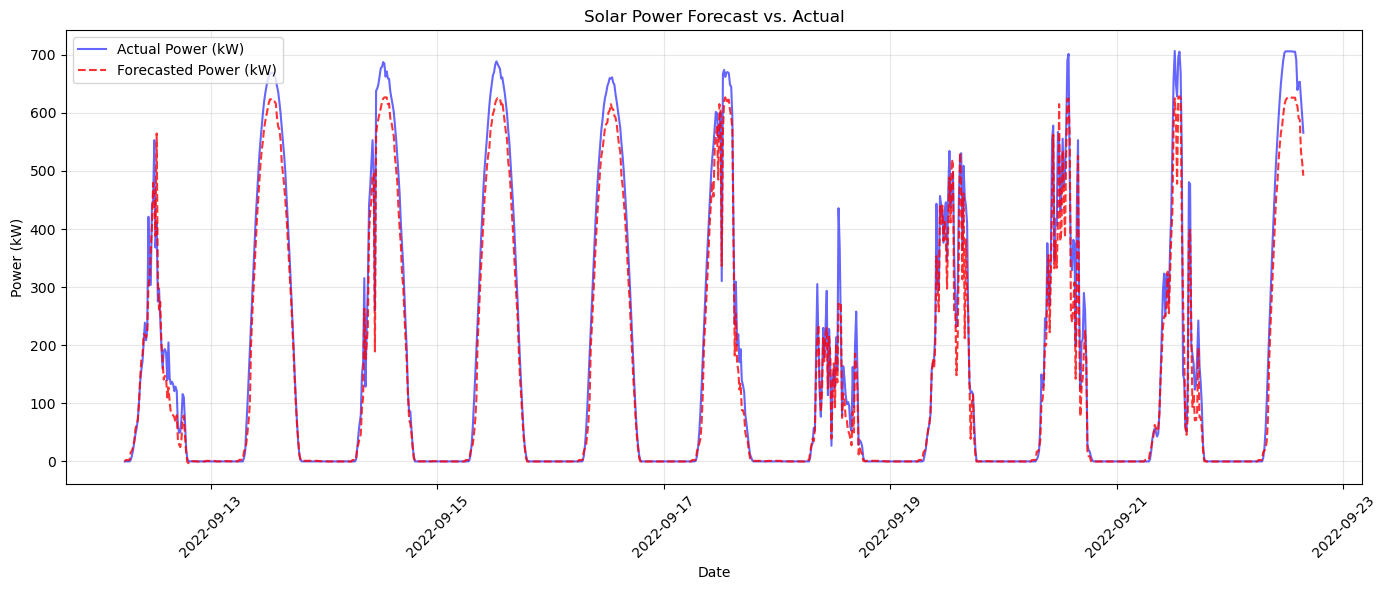

In [15]:
test_dates = pd.to_datetime(df_test['measured_on'], utc=True)

plt.figure(figsize=(14, 6))
plot_ind = 1000

plt.plot(test_dates[:plot_ind], Y_test.values[:plot_ind], label='Actual Power (kW)', color='blue', alpha=0.6, linewidth=1.5)
plt.plot(test_dates[:plot_ind], final_predictions[:plot_ind], label='Forecasted Power (kW)', color='red', alpha=0.8, linewidth=1.5, linestyle='--')

plt.title('Solar Power Forecast vs. Actual')
plt.xlabel('Date')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()